In [2]:
import pandas as pd
import warnings
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'insurance.csv')
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [4]:
df.tail(2)

,age,sex,bmi,children,smoker,region,charges
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
smoker_palette = {'yes': 'lightcoral', 'no': 'skyblue'}

In [6]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


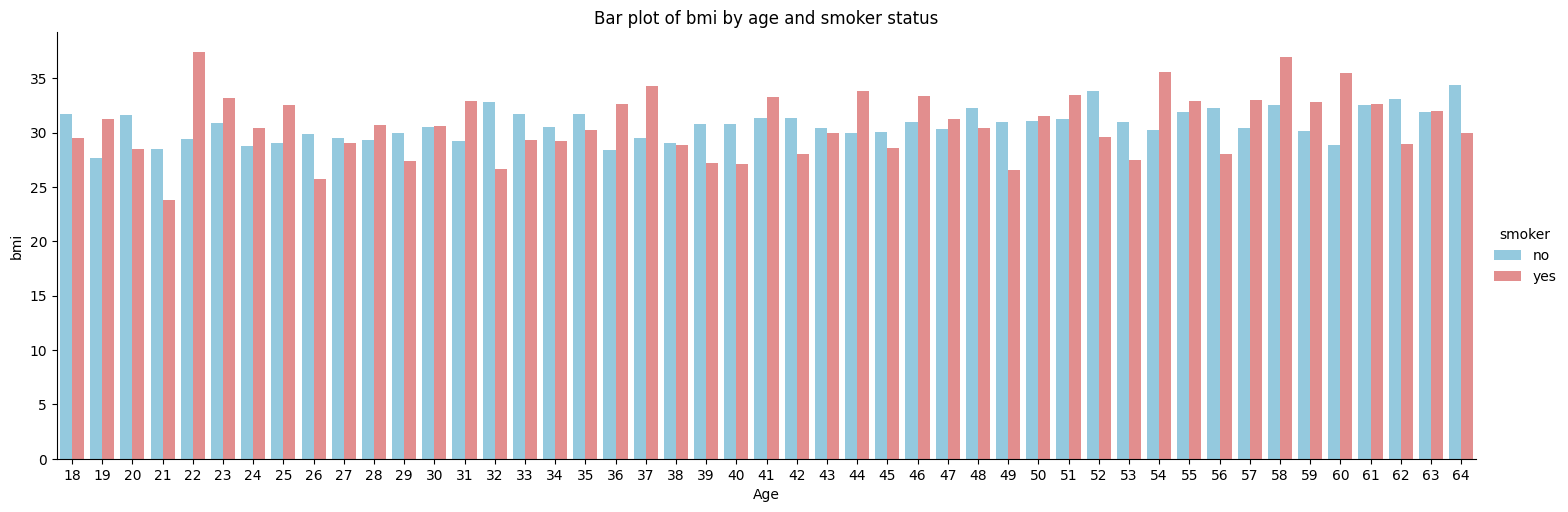

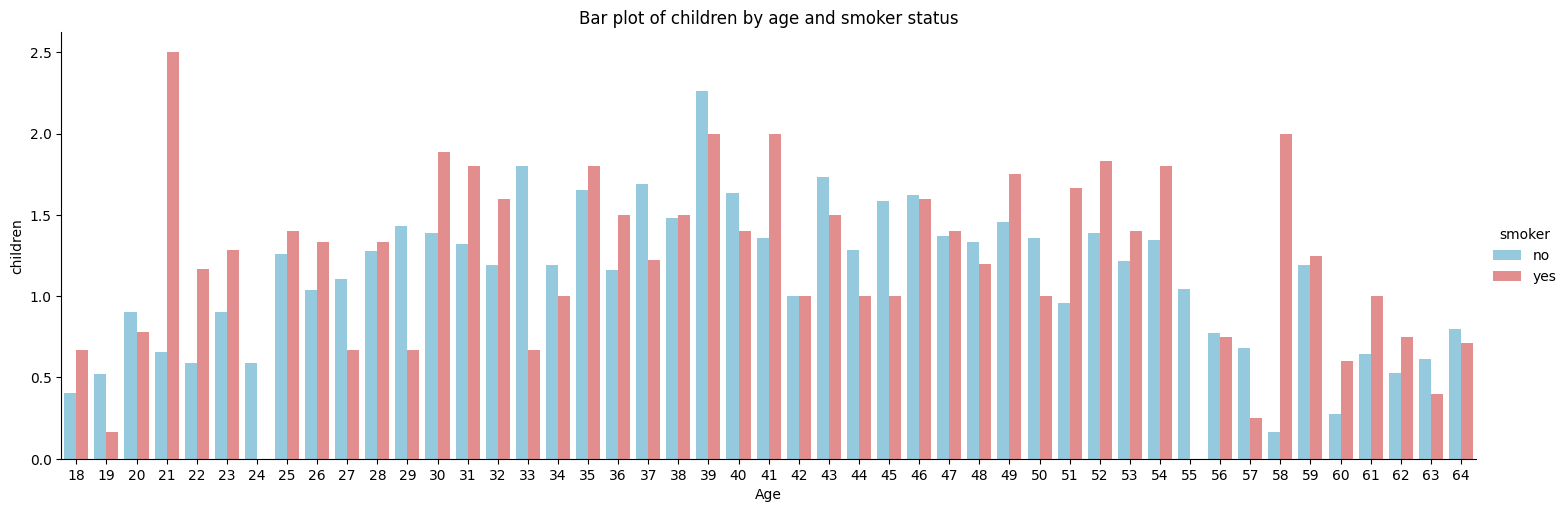

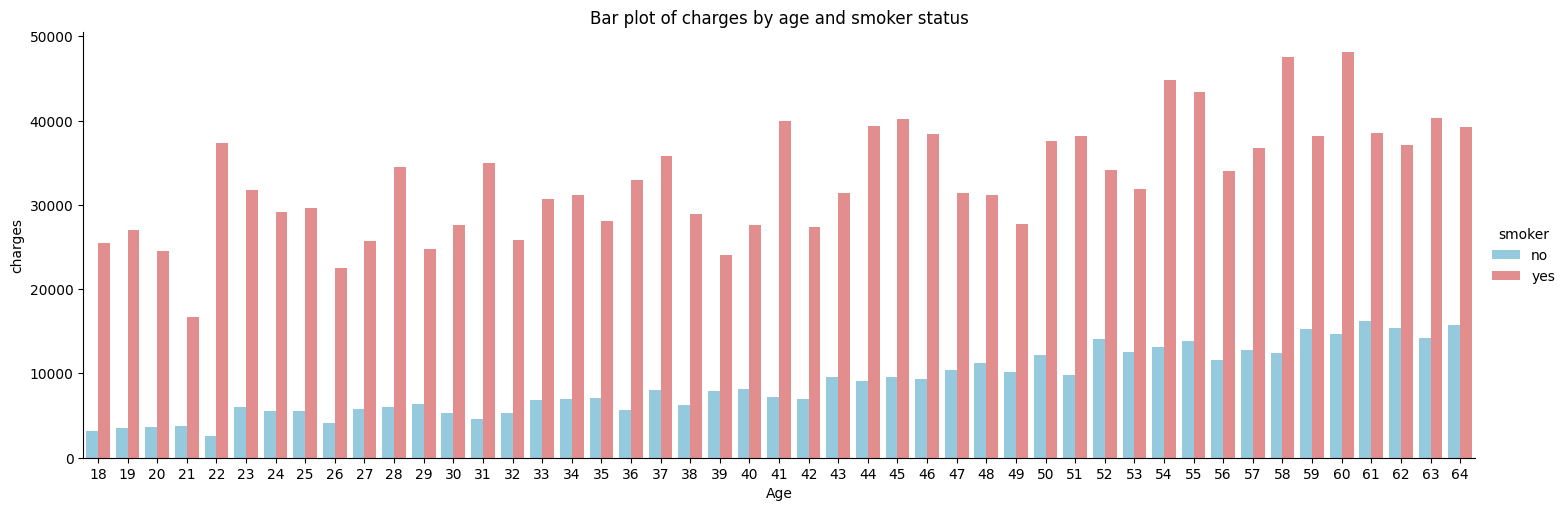

In [44]:
for i in df.select_dtypes('number').columns.drop(['age']):
    sns.catplot(x="age", y=i, data=df, hue='smoker', kind='bar', aspect=3, errorbar=None, palette=smoker_palette)
    plt.title(f'Bar plot of {i} by age and smoker status')
    plt.xlabel('Age')
    plt.ylabel(i)
    plt.title(f'Bar plot of {i} by age and smoker status')
    plt.show()

<Axes: >

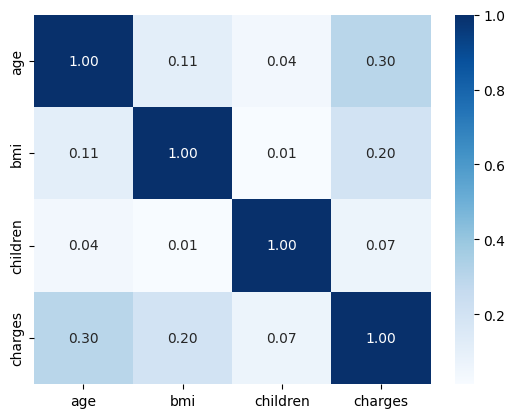

In [8]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='Blues', fmt='.2f')

Smokers usually have higher costs than non-smokers, so we can visualize the relationship between age, smoker status, and other numerical features in the dataset. The following code generates bar plots for each numerical feature against age, colored by smoker status.


In [9]:
df.isna().sum() # a perfect data

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

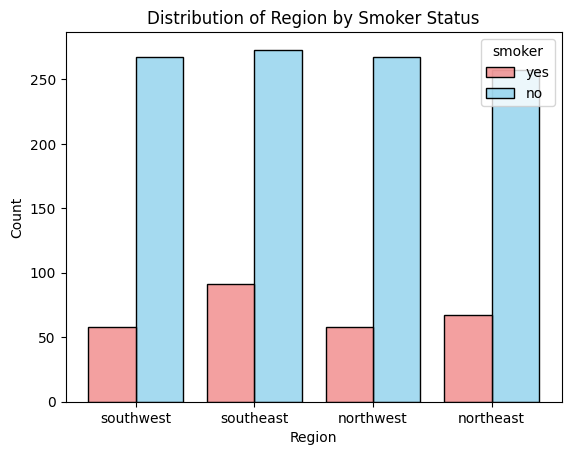

In [11]:
sns.histplot(data=df, x='region', hue='smoker', multiple='dodge', shrink=0.8, edgecolor='black', palette=smoker_palette)
plt.title('Distribution of Region by Smoker Status')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

In [12]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [13]:
df['health_condition'] = np.select(
    [
        (df['bmi'] < 18.5),  # Underweight
        (df['bmi'] >= 18.5) & (df['bmi'] < 24.9),
        (df['bmi'] >= 24.9) & (df['bmi'] < 29.9),
        (df['bmi'] >= 29.9) & (df['bmi'] < 34.9),
        (df['bmi'] >= 34.9) & (df['bmi'] < 39.9),
        (df['bmi'] >= 39.9)  
    ],
    [
        'Underweight',   'Normal weight', 'Overweight', 'Obesity class I',
        'Obesity class II', 'Obesity class III'],
    default = 'Unknown'
)

In [14]:
df['health_condition'].value_counts()

health_condition
Obesity class I      399
Overweight           377
Obesity class II     226
Normal weight        222
Obesity class III     94
Underweight           20
Name: count, dtype: int64

In [15]:
high_risk_conditions = df[(df['bmi'] >= 29.9) & (df['smoker'] == 'yes')]
np.mean(high_risk_conditions['charges'])
low_risk_conditions = df[(df['bmi'] < 29.9) & (df['smoker'] == 'no')]
np.mean(low_risk_conditions['charges'])

np.float64(8002.59602379878)

<Axes: xlabel='charges', ylabel='Density'>

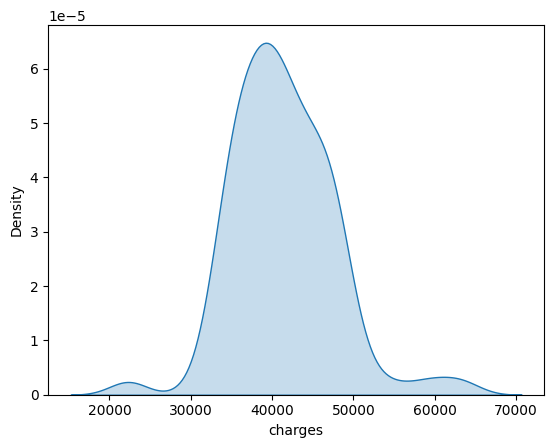

In [16]:
sns.kdeplot(data=high_risk_conditions, x='charges', fill=True)

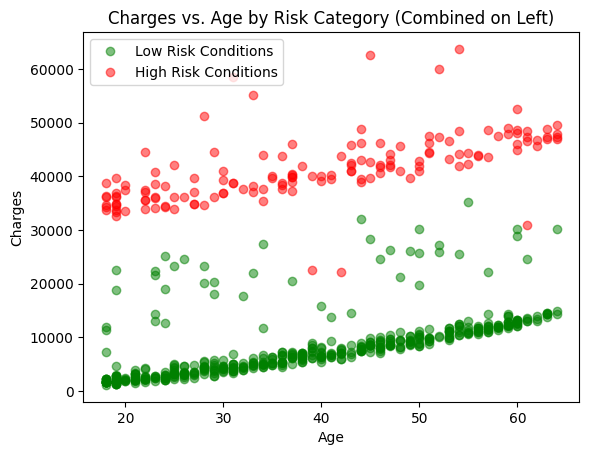

In [17]:
fig, ax = plt.subplots()
ax.plot(low_risk_conditions['age'], low_risk_conditions['charges'],
           'o', alpha=0.5, label='Low Risk Conditions', color='green')
ax.plot(high_risk_conditions['age'], high_risk_conditions['charges'],
           'o', alpha=0.5, label='High Risk Conditions', color='red')
ax.set_xlabel('Age')
ax.set_ylabel('Charges')
ax.set_title('Charges vs. Age by Risk Category (Combined on Left)')
ax.legend()


Here we can see the group who have higher bmi and are smokers, has a high average charge. On the other hand, the group with lower bmi and non-smokers has a lower average charge. This suggests that both smoking status and bmi are significant factors in determining insurance charges.

# AI Models

In [18]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.compose import ColumnTransformer

In [19]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'health_condition'],
      dtype='object')

In [20]:
X = df.drop(columns=['charges', 'health_condition'])
y = df['charges']

In [21]:
categorical = ['sex', 'smoker', 'region']
numerical = ['age', 'bmi', 'children']

In [22]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler())]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numerical_transformer, numerical)
    ]
)


In [23]:
models = {
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'Ridge': Ridge(alpha=.1),
    'Lasso': Lasso(alpha=.1)    
}

In [24]:
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                               ("model", model)])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-scores)
    results[name] = {
        "RMSE Mean": rmse_scores.mean(),
        "RMSE Std": rmse_scores.std()
    }
    
results_df = pd.DataFrame(results).T.sort_values(by = 'RMSE Mean', ascending=True)
print(results_df)

                         RMSE Mean    RMSE Std
RandomForestRegressor  4828.536873  372.518781
KNeighborsRegressor    6000.834364  176.043607
Lasso                  6072.390427  197.892053
Ridge                  6072.405063  197.683588
DecisionTreeRegressor  6564.473837  196.312503


Looks like RandomForestRegressor is the best model for this dataset, with a mean RMSE of 0.0. This indicates that the model is able to predict the insurance charges with high accuracy. Now we can use this model to make predictions on new data.

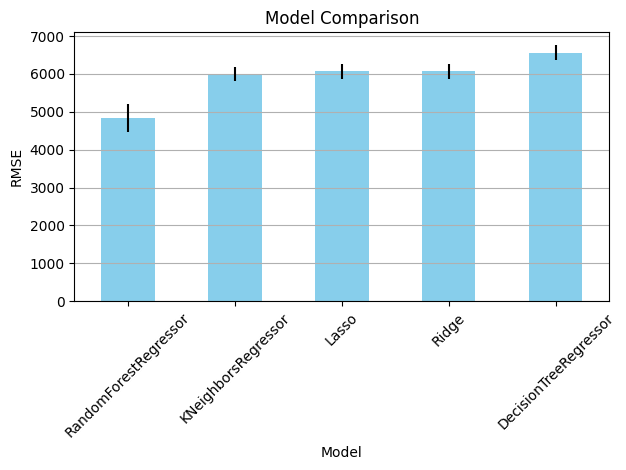

In [25]:
results_df.plot(kind='bar', y='RMSE Mean', yerr='RMSE Std', legend=False, color='skyblue')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.title('Model Comparison')
plt.grid(True, axis = 'y')
plt.tight_layout()
plt.show()

In [ ]:
rf_pipeline = Pipeline(
    steps = [
    ('preprocessro', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
    ]
)

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_search_model = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)


grid_search_model.fit(X, y)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessro',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region']),
                                                                        ('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20, 30],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=1)

In [27]:
print("Best Parameters:", grid_search_model.best_params_)
print("Best RMSE Score:", np.sqrt(-grid_search_model.best_score_))

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best RMSE Score: 4576.934117262468


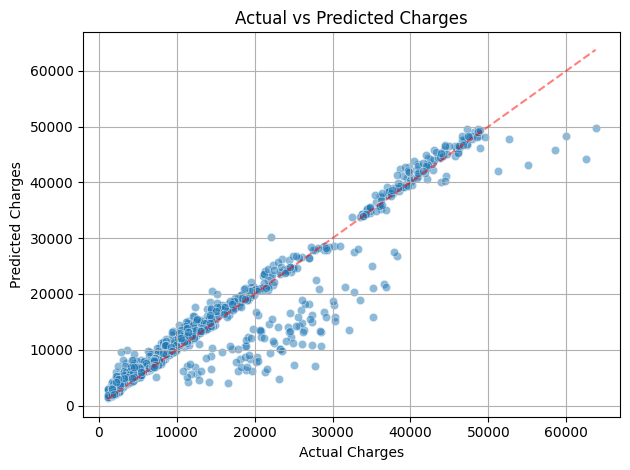

In [28]:
y_pred = grid_search_model.predict(X)



plt.figure()
sns.scatterplot(x=y, y=y_pred, alpha=0.5, markers='o', edgecolor='w')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', alpha = 0.5)
plt.grid('True')
plt.title('Actual vs Predicted Charges')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_980\7313176.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 5)` for the same effect.

  sns.barplot(x=X['region'], y=y_pred, alpha=0.5, ci = 5)


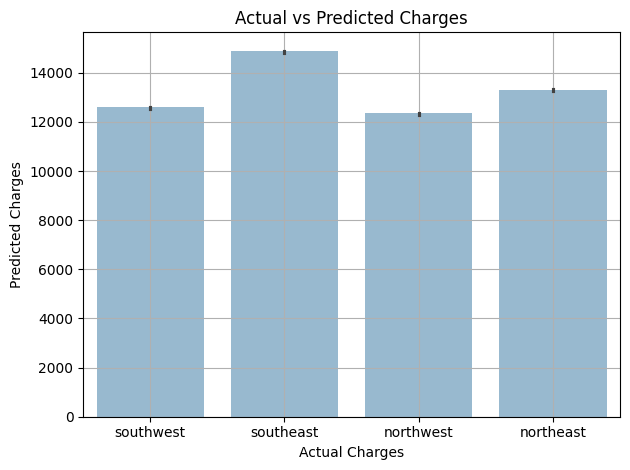

In [42]:
plt.figure()
sns.barplot(x=X['region'], y=y_pred, alpha=0.5, ci = 5)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.grid('True')
plt.title('Actual vs Predicted Charges')
plt.tight_layout()
plt.show()